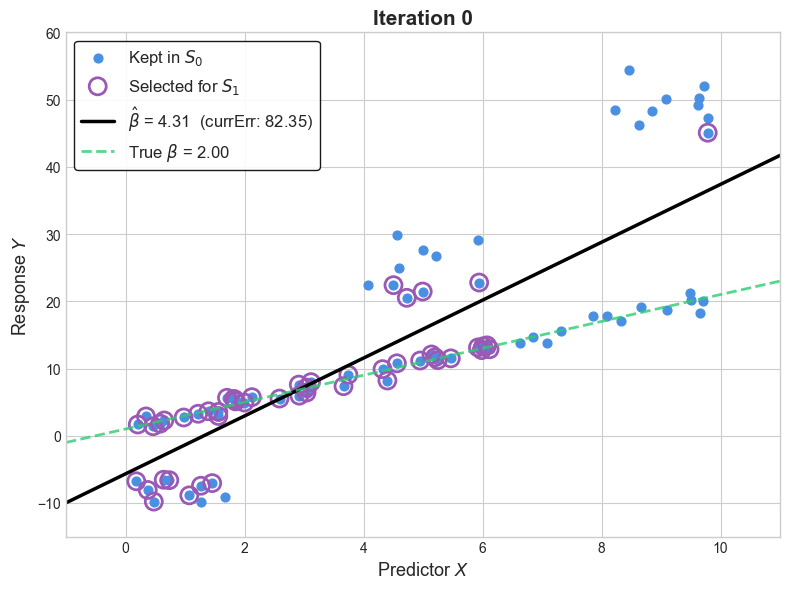

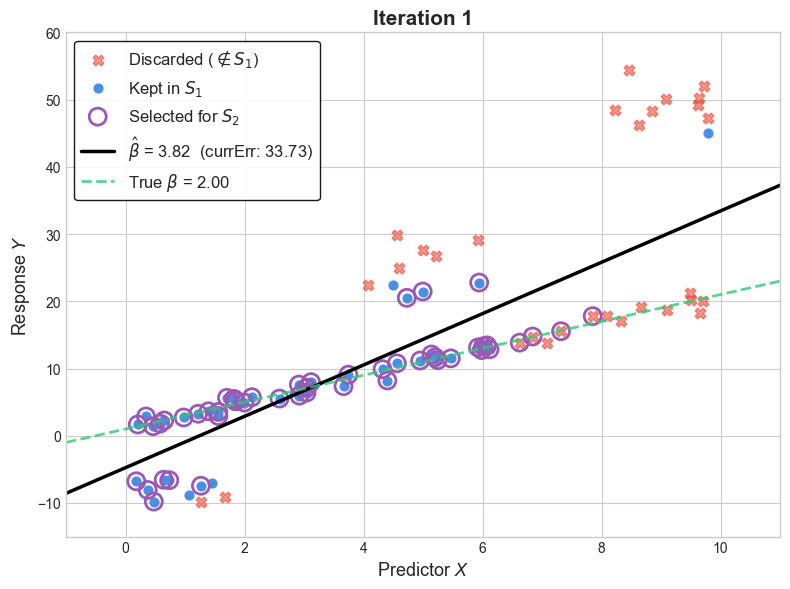

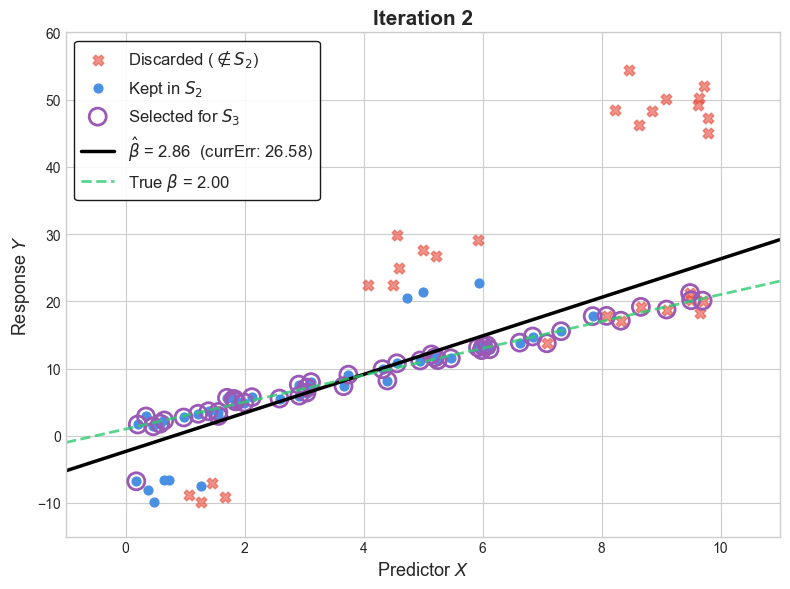

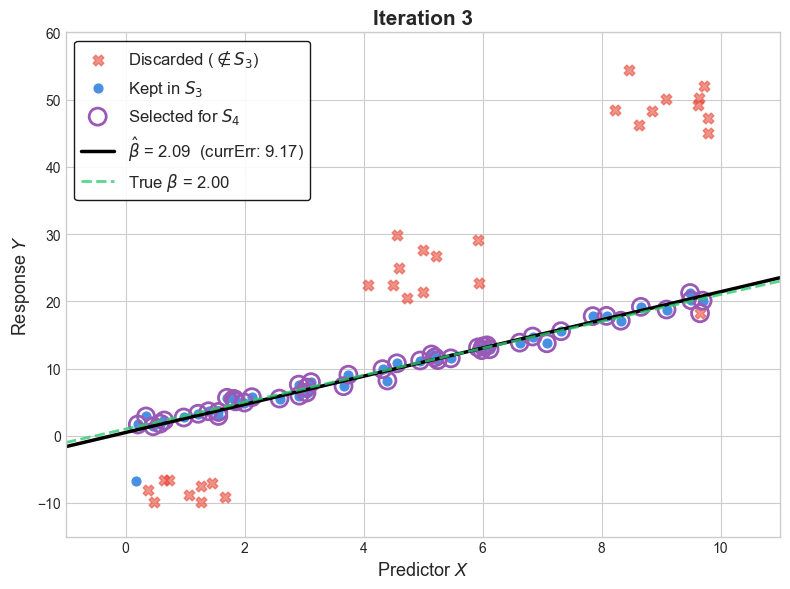

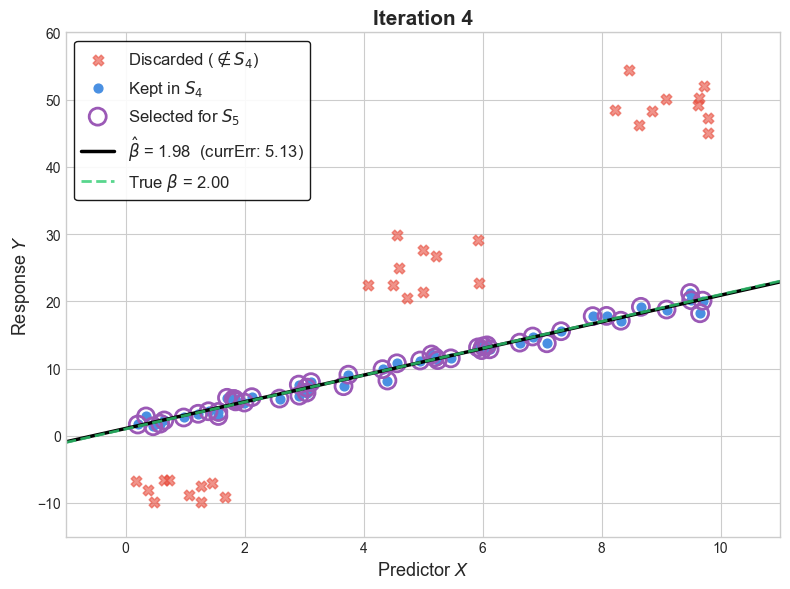

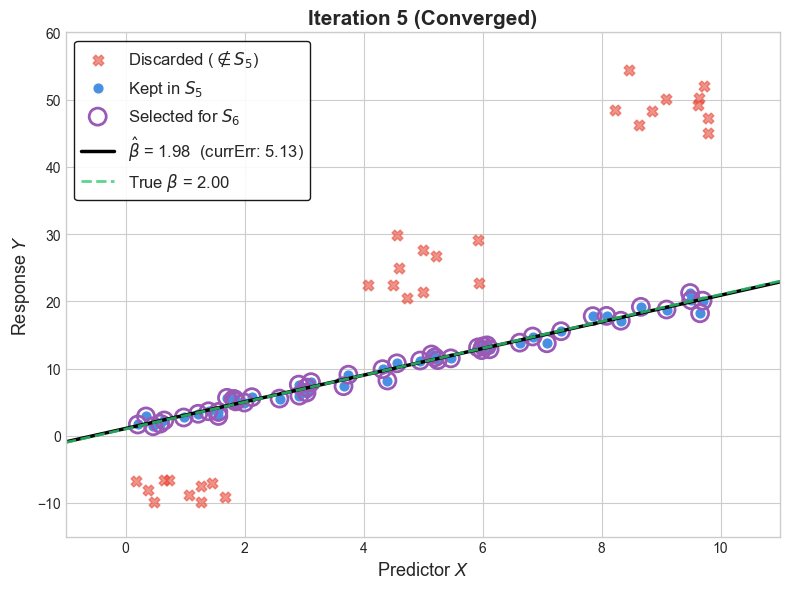

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- 1. Generate "Breadcrumb" Adversarial Data ---
np.random.seed(42)

n_clean = 50
X_clean = np.random.uniform(0, 10, n_clean)
Y_clean = 2.0 * X_clean + 1.0 + np.random.normal(0, 0.8, n_clean)

X_outA = np.random.uniform(8, 10, 10)
Y_outA = np.random.uniform(45, 55, 10)

X_outB = np.random.uniform(4, 6, 10)
Y_outB = np.random.uniform(20, 30, 10)

X_outC = np.random.uniform(0, 2, 10)
Y_outC = np.random.uniform(-10, -5, 10)

X = np.concatenate([X_clean, X_outA, X_outB, X_outC])
Y = np.concatenate([Y_clean, Y_outA, Y_outB, Y_outC])
n = len(X)
a = 50

# --- 2. The Torrent Algorithm Logic ---
history_S = []
history_models = []
S_t = np.arange(n) # Start with all points

# Initialize error variables matching the theoretical pseudo-code
currErr = np.linalg.norm(Y)
lastErr = float('inf')
t = 0
max_iters = 15

# Loop as long as the error is strictly decreasing
# Stop if the error doesn't drop by at least a tiny threshold
while currErr < (lastErr - 1e-4) and t < max_iters:

    # Fit OLS on current clean subset
    X_curr = X[S_t].reshape(-1, 1)
    Y_curr = Y[S_t]
    model = LinearRegression().fit(X_curr, Y_curr)

    history_S.append(S_t.copy())
    history_models.append(model)

    # Calculate residuals on ALL points
    preds_all = model.predict(X.reshape(-1, 1))
    v = np.abs(Y - preds_all)

    # Hard Thresholding: keep indices of the 'a' smallest residuals
    S_t = np.argsort(v)[:a]

    # Update errors for the while condition check
    lastErr = currErr

    # Calculate the new error on the newly chosen subset (S_t) using the current model
    X_next = X[S_t].reshape(-1, 1)
    Y_next = Y[S_t]
    preds_next = model.predict(X_next)
    currErr = np.linalg.norm(Y_next - preds_next)

    t += 1

# --- 3. Visualization (Separate Plots) ---
plt.style.use('seaborn-v0_8-whitegrid')
x_plot = np.linspace(-1, 11, 100).reshape(-1, 1)

num_models = len(history_models)
plot_indices = list(range(num_models))

for i in plot_indices:
    fig, ax = plt.subplots(figsize=(8, 6))

    current_S = history_S[i]
    current_model = history_models[i]

    X_subset = X[current_S].reshape(-1, 1)
    Y_subset = Y[current_S]
    preds_subset = current_model.predict(X_subset)
    current_err = np.linalg.norm(Y_subset - preds_subset)

    preds_all = current_model.predict(X.reshape(-1, 1))
    all_residuals = np.abs(Y - preds_all)
    next_S = np.argsort(all_residuals)[:a]

    clean_mask = np.zeros(n, dtype=bool)
    clean_mask[current_S] = True
    discarded_mask = ~clean_mask

    next_mask = np.zeros(n, dtype=bool)
    next_mask[next_S] = True

    # 2. Plot points currently discarded
    if np.any(discarded_mask):
        ax.scatter(X[discarded_mask], Y[discarded_mask], color='#E74C3C', marker='X', s=60, alpha=0.6, label=rf'Discarded ($\notin S_{{{i}}}$)')

    # 1. Plot points currently in S_t
    ax.scatter(X[clean_mask], Y[clean_mask], color='#4A90E2', s=40, label=f'Kept in $S_{{{i}}}$')

    # 3. OVERLAY: Circle the points selected for S_{t+1}
    ax.scatter(X[next_mask], Y[next_mask], facecolors='none', edgecolors='#9B59B6', s=150, linewidths=2, label=f'Selected for $S_{{{i+1}}}$')

    # Plot lines
    ax.plot(x_plot, current_model.predict(x_plot), color='black', linewidth=2.5,
            label=rf'$\hat{{\beta}}$ = {current_model.coef_[0]:.2f}  (currErr: {current_err:.2f})')
    ax.plot(x_plot, 2.0 * x_plot + 1.0, color='#2ECC71', linestyle='--', linewidth=2, alpha=0.8, label=r'True $\beta$ = 2.00')

    if i == num_models - 1:
        ax.set_title(f'Iteration {i} (Converged)', fontsize=15, fontweight='bold')
    else:
        ax.set_title(f'Iteration {i}', fontsize=15, fontweight='bold')

    ax.set_xlabel('Predictor $X$', fontsize=13)
    ax.set_ylabel('Response $Y$', fontsize=13)

    ax.set_xlim(-1, 11)
    ax.set_ylim(-15, 60)

    # --- LEGEND PUT BACK INSIDE ---
    ax.legend(loc='upper left', fontsize=12, markerscale=1.0, frameon=True, edgecolor='black', framealpha=0.9)

    plt.tight_layout()

    filename = f'torrent_iter_{i}_converged.pdf' if i == num_models - 1 else f'torrent_iter_{i}.pdf'
    plt.savefig(filename, format='pdf', bbox_inches='tight')

    plt.show()
    plt.close(fig)